# 🏆 Season Analysis Pipeline
## `2026` Formula 1 World Championship

The **data-engineering centerpiece**: ingest every completed race into one tidy dataset,
persist it, then derive championship standings and teammate battles from the clean table.

Re-run after each race — `build_season_dataset` re-reads only what's cached + the new round.

---

In [10]:
YEAR = 2026
REBUILD = True   # True = (re)download & rebuild dataset; False = load saved data/

In [11]:
import sys, os
from pathlib import Path

_here = Path(os.getcwd()).resolve()
_root = _here
for _ in range(5):
    if (_root / 'utils' / 'f1_helpers.py').exists():
        break
    _root = _root.parent
sys.path.insert(0, str(_root))

from utils.f1_helpers import setup, ensure_assets_dir
from utils.season_etl import (
    build_season_dataset, load_season_dataset,
    driver_standings, constructor_standings,
    plot_championship_progression,
    teammate_battles, plot_teammate_battles,
)

setup('content/f1_cache')
ASSETS = ensure_assets_dir('assets')

---
## 1 · Extract & Transform — build the tidy dataset

In [ ]:
if REBUILD:
    df = build_season_dataset(YEAR, session_type='R')
else:
    df = load_season_dataset(YEAR)

print(f'\nDataset shape: {df.shape}')
df.head()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info

  ✓ Round  1 Australian Grand Prix: 22 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 12 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '87', '10', '30', '6', '55', '43', '27', '41', '77', '31', '11', '3', '14', '18', '81', '1', '5', '23']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  ✓ Round  2 Chinese Grand Prix: 22 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 22 drivers: ['12', '81', '16', '63', '1', '44', '10', '3', '30', '31', '27', '6', '5', '41', '55', '43', '11', '14', '77', '23', '18', '87']
core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


...

req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core           INFO 	Finished loading data for 22 drivers: ['44', '63', '1', '3', '81', '6', '10', '30', '41', '43', '5', '55', '31', '11', '16', '12', '87', '23', '14', '27', '77', '18']
core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


  ✓ Round  7 Barcelona Grand Prix: 22 drivers


logger      WARNING 	Failed to load session info data!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
core        WARNING 	Failed to load extended driver information!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
core        WARNING 	Failed to load driver list and session results!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
logger      WARNING 	Failed to load session status data!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
logger      WARNING 	Failed to load total lap count!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
logger      WARNING 	Failed to load track status data!
req            INFO 	No 

  · Round  8 Austrian Grand Prix: no results yet


logger      WARNING 	Failed to load session info data!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
core        WARNING 	Failed to load extended driver information!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
core        WARNING 	Failed to load driver list and session results!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
logger      WARNING 	Failed to load session status data!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
logger      WARNING 	Failed to load total lap count!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
logger      WARNING 	Failed to load track status data!
req            INFO 	No 

---
## 2 · Championship Standings

In [ ]:
driver_standings(df).head(15)

,Driver,Team,Points
Pos,,,
1,ANT,Mercedes,143.0
2,HAM,Ferrari,104.0
3,RUS,Mercedes,85.0
4,LEC,Ferrari,58.0
5,NOR,McLaren,53.0
6,PIA,McLaren,53.0
7,VER,Red Bull Racing,49.0
8,GAS,Alpine,40.0
9,HAD,Red Bull Racing,34.0


In [ ]:
constructor_standings(df)

,Team,Points
Pos,,
1,Mercedes,228.0
2,Ferrari,162.0
3,McLaren,106.0
4,Red Bull Racing,83.0
5,Alpine,56.0
6,Racing Bulls,38.0
7,Haas F1 Team,20.0
8,Williams,11.0
9,Audi,2.0


findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.


Saved → assets\S1_championship_progression.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_68052\3175934157.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


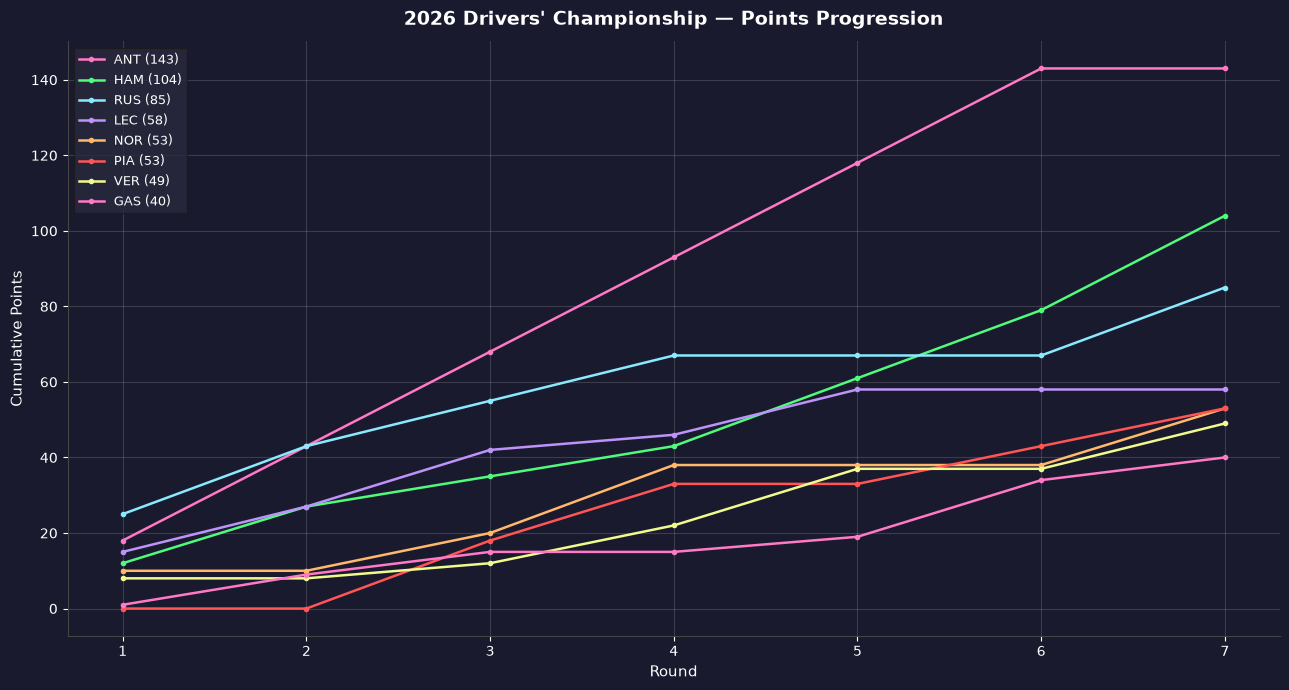

In [ ]:
fig1 = plot_championship_progression(df, top_n=8, assets_path=ASSETS)
fig1.show()

---
## 3 · Teammate Battles

In [ ]:
battles = teammate_battles(df)
battles

,Team,Driver1,Driver2,Race_D1,Race_D2,Quali_D1,Quali_D2,Points_D1,Points_D2
0,Alpine,GAS,COL,5,2,4,3,40,16
1,Aston Martin,STR,ALO,2,5,1,6,0,1
2,Audi,BOR,HUL,4,3,2,5,2,0
3,Cadillac,PER,BOT,5,2,5,2,0,0
4,Ferrari,LEC,HAM,2,5,3,4,58,104
5,Haas F1 Team,BEA,OCO,4,3,5,2,17,3
6,McLaren,NOR,PIA,3,4,3,4,53,53
7,Mercedes,RUS,ANT,2,5,3,4,85,143
8,Racing Bulls,LIN,LAW,2,5,2,5,12,26
9,Red Bull Racing,VER,HAD,5,2,5,2,49,34


Saved → assets\S2_teammate_battles.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_68052\1082235079.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


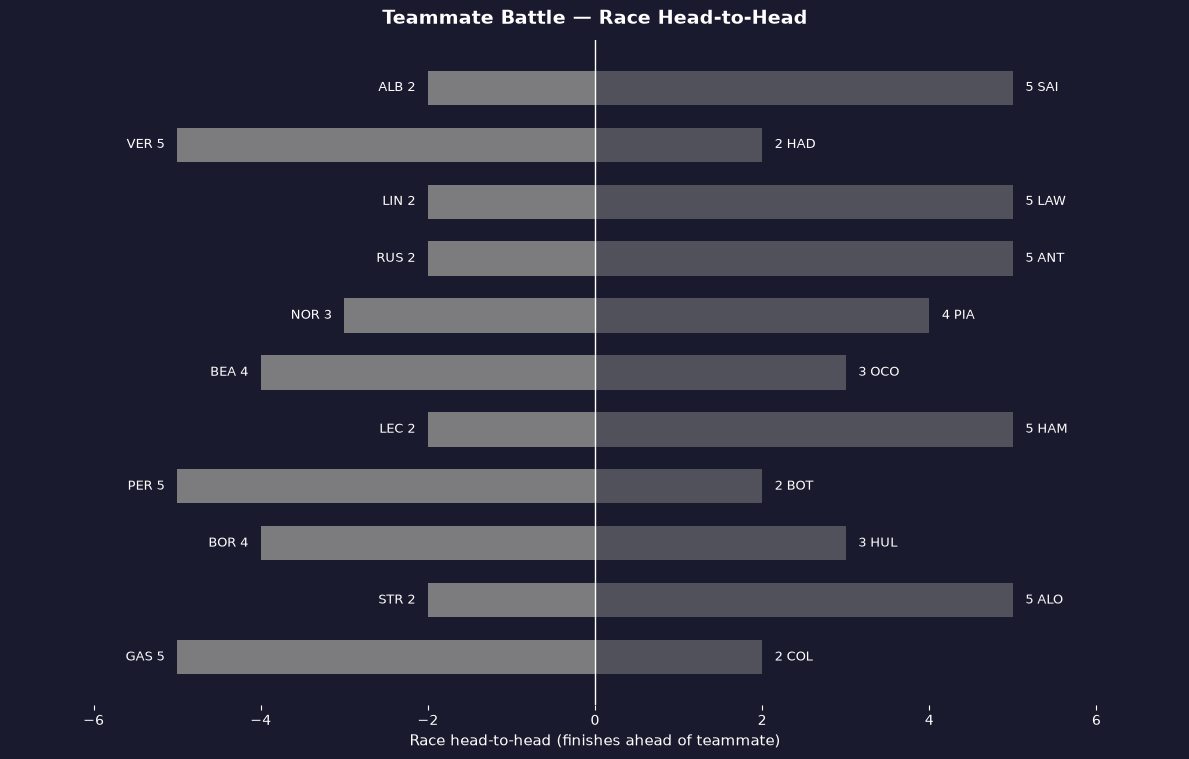

In [ ]:
fig2 = plot_teammate_battles(battles, assets_path=ASSETS)
fig2.show()

---
## 4 · LinkedIn Post Draft

In [ ]:
ds = driver_standings(df)
cs = constructor_standings(df)
n_rounds = df['Round'].nunique()
leader = ds.iloc[0]

post = f"""
🏆 {YEAR} F1 Championship — State of Play after {n_rounds} rounds

I built a pipeline that ingests every race into one tidy dataset, then derives
the standings and teammate battles automatically. Numbers, not vibes 📊

🥇 Championship leader: {leader['Driver']} ({int(leader['Points'])} pts)
🏭 Leading constructor: {cs.iloc[0]['Team']} ({int(cs.iloc[0]['Points'])} pts)

⚔️ Closest teammate battle: [from the battles table]
📈 Biggest climber this stretch: [your read]

Built with Python + FastF1. Full pipeline + notebooks on GitHub 👇

#Formula1 #F1 #DataEngineering #DataAnalysis #Python #FastF1 #Motorsport
"""
print(post)


🏆 2026 F1 Championship — State of Play after 7 rounds

I built a pipeline that ingests every race into one tidy dataset, then derives
the standings and teammate battles automatically. Numbers, not vibes 📊

🥇 Championship leader: ANT (143 pts)
🏭 Leading constructor: Mercedes (228 pts)

⚔️ Closest teammate battle: [from the battles table]
📈 Biggest climber this stretch: [your read]

Built with Python + FastF1. Full pipeline + notebooks on GitHub 👇

#Formula1 #F1 #DataEngineering #DataAnalysis #Python #FastF1 #Motorsport



---
## Outputs

| File | Description |
|------|-------------|
| `data/season_{YEAR}.csv` / `.parquet` | The tidy dataset (the ETL deliverable) |
| `assets/S1_championship_progression.png` | Points progression line chart |
| `assets/S2_teammate_battles.png` | Teammate head-to-head diverging bars |

Every other notebook can now `load_season_dataset(YEAR)` instead of re-downloading.